# 📡 03 — Спектральные индексы

Цель: вычислить признаки на основе спектральных индексов и понять, насколько хорошо они разделяют классы.

Вместо того чтобы подавать в модель сырые значения каналов, мы создаём **безразмерные индексы** — нормализованные отношения между каналами. Они инвариантны к яркости и лучше описывают физические свойства покрова.

| Индекс | Формула | Что показывает |
|--------|---------|----------------|
| NDVI | (NIR − Red) / (NIR + Red) | Растительность/водоросли |
| NDWI | (Green − NIR) / (Green + NIR) | Водная поверхность |
| FAI  | NIR − Red − (SWIR1−Red)·const | Плавающие водоросли |
| FDI  | NIR − RE2 − (SWIR1−RE2)·const | Плавающий мусор |
| PI   | NIR / (NIR + Red) | Пластик (высокий NIR) |
| NDMI | (NIR − SWIR1) / (NIR + SWIR1) | Влажность |
| RE   | (RE1 − Red) / (RE1 + Red) | Красный край |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH    = Path(r"c:\Users\Amir\Desktop\EcoHack\data")
PATCHES_PATH = DATA_PATH / "patches"
SPLITS_PATH  = DATA_PATH / "splits"

LABEL_REMAP = {
    0: None, 1: 0, 2: 1, 3: 1, 4: 1,
    5: None, 6: None, 7: 3, 8: 2, 9: 3, 10: 3, 11: 2,
}
TARGET_NAMES = {0: "Мусор", 1: "Водоросли", 2: "Пена", 3: "Вода"}
CLASS_COLORS = {0: "#E74C3C", 1: "#2ECC71", 2: "#F1C40F", 3: "#3498DB"}
BAND_NAMES   = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12"]
BAND_WL      = [443, 490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]

def load_split(name):
    path = SPLITS_PATH / f"{name}_X.txt"
    return [l.strip() for l in path.read_text().splitlines() if l.strip()]

def patch_paths(patch_id):
    parts = patch_id.rsplit("_", 1)
    scene = "S2_" + parts[0]
    base  = PATCHES_PATH / scene / f"{scene}_{parts[1]}"
    return base.with_suffix(".tif"), Path(str(base) + "_cl.tif")

def normalize_band(band, p_low=2, p_high=98):
    lo, hi = np.percentile(band, [p_low, p_high])
    return np.clip((band - lo) / (hi - lo + 1e-9), 0, 1)

def make_rgb(img):
    return np.stack([normalize_band(img[3]), normalize_band(img[2]), normalize_band(img[1])], axis=2)

def label_to_4class(lbl):
    out = np.full(lbl.shape, -1, dtype=np.int8)
    for s, t in LABEL_REMAP.items():
        if t is not None:
            out[lbl == s] = t
    return out

train_ids = load_split("train")
print("Загружено", len(train_ids), "обучающих патчей")

Загружено 694 обучающих патчей


## 1. Вычисление каждого индекса (пошагово)

Разберём каждый индекс отдельно — формула, физический смысл, диапазон значений.

In [3]:
# Загружаем пример патча для демонстрации
sample_pid = train_ids[5]
ip, lp = patch_paths(sample_pid)

with rasterio.open(ip) as s:
    img = s.read().astype(np.float32)   # (11, H, W)
with rasterio.open(lp) as s:
    lbl = s.read(1).astype(np.uint8)

lbl4 = label_to_4class(lbl)

# Именуем каналы для удобства
B02 = img[1];  B03 = img[2];  B04 = img[3]
B05 = img[4];  B06 = img[5]
B08 = img[7];  B8A = img[8]
B11 = img[9];  B12 = img[10]

eps = 1e-6
print(f"Патч: {sample_pid}, размер: {img.shape[1]}×{img.shape[2]}")

Патч: 11-1-19_19QDA_1, размер: 256×256


In [4]:
# NDVI — нормализованный вегетационный индекс
# Формула: (NIR - Red) / (NIR + Red)
# Диапазон: [-1, 1]. Высокие значения → живая растительность/водоросли
ndvi = (B8A - B04) / (B8A + B04 + eps)

print(f"NDVI:  min={ndvi.min():.3f}  max={ndvi.max():.3f}  mean={ndvi.mean():.3f}")
print(f"  > 0.3 (водоросли/растения): {(ndvi > 0.3).sum()} пкс ({100*(ndvi>0.3).mean():.1f}%)")
print(f"  < 0.0 (вода/голая поверхн): {(ndvi < 0.0).sum()} пкс ({100*(ndvi<0.0).mean():.1f}%)")

NDVI:  min=-0.504  max=0.835  mean=0.177
  > 0.3 (водоросли/растения): 17022 пкс (26.0%)
  < 0.0 (вода/голая поверхн): 14512 пкс (22.1%)


In [5]:
# NDWI — нормализованный водный индекс (McFeeters 1996)
# Формула: (Green - NIR) / (Green + NIR)
# Диапазон: [-1, 1]. Высокие → вода, низкие → суша/растения
ndwi = (B03 - B8A) / (B03 + B8A + eps)

print(f"NDWI:  min={ndwi.min():.3f}  max={ndwi.max():.3f}  mean={ndwi.mean():.3f}")
print(f"  > 0.0 (вода): {(ndwi > 0.0).sum()} пкс ({100*(ndwi>0.0).mean():.1f}%)")

NDWI:  min=-0.766  max=0.724  mean=-0.153
  > 0.0 (вода): 14295 пкс (21.8%)


In [6]:
# FAI — Floating Algae Index (Hu 2009)
# Обнаруживает скопления сине-зелёных водорослей и саргасс
# Формула: B8A - B04 - (B11 - B04) * (865-665) / (1610-665)
# Положительные значения → плавающая биомасса
fai = B8A - B04 - (B11 - B04) * (865 - 665) / (1610 - 665)

print(f"FAI:   min={fai.min():.1f}  max={fai.max():.1f}  mean={fai.mean():.2f}")
print(f"  > 0 (плавающие водоросли): {(fai > 0).sum()} пкс ({100*(fai>0).mean():.1f}%)")

FAI:   min=-0.7  max=0.4  mean=0.05
  > 0 (плавающие водоросли): 53225 пкс (81.2%)


In [7]:
# FDI — Floating Debris Index (Biermann et al. 2020)
# Специально разработан для обнаружения плавающего пластикового мусора
# Формула: B08 - B06 - (B11 - B06) * (833-740) / (1610-740)
fdi = B08 - B06 - (B11 - B06) * (833 - 740) / (1610 - 740)

print(f"FDI:   min={fdi.min():.2f}  max={fdi.max():.2f}  mean={fdi.mean():.3f}")

FDI:   min=-0.27  max=0.68  mean=0.001


In [8]:
# PI — Plastic Index (Garaba et al. 2018)
# Пластик отражает больше в NIR относительно Red
# Формула: B8A / (B8A + B04)
pi = B8A / (B8A + B04 + eps)

print(f"PI:    min={pi.min():.3f}  max={pi.max():.3f}  mean={pi.mean():.3f}")
print(f"  Теоретический диапазон: [0, 1]; пластик → близко к 0.5-0.7")

PI:    min=0.248  max=0.918  mean=0.588
  Теоретический диапазон: [0, 1]; пластик → близко к 0.5-0.7


In [9]:
# NDMI — нормализованный индекс влажности
# Формула: (NIR - SWIR1) / (NIR + SWIR1)
ndmi = (B8A - B11) / (B8A + B11 + eps)

print(f"NDMI:  min={ndmi.min():.3f}  max={ndmi.max():.3f}  mean={ndmi.mean():.3f}")

NDMI:  min=-0.335  max=0.621  mean=0.101


In [10]:
# RE — Red-Edge Index (красный край)
# Чувствителен к хлорофиллу, отличает живые водоросли от мусора
# Формула: (B05 - B04) / (B05 + B04)
re_idx = (B05 - B04) / (B05 + B04 + eps)

print(f"RE:    min={re_idx.min():.3f}  max={re_idx.max():.3f}  mean={re_idx.mean():.3f}")

RE:    min=-0.564  max=0.558  mean=0.016


## 2. Визуализация карт индексов

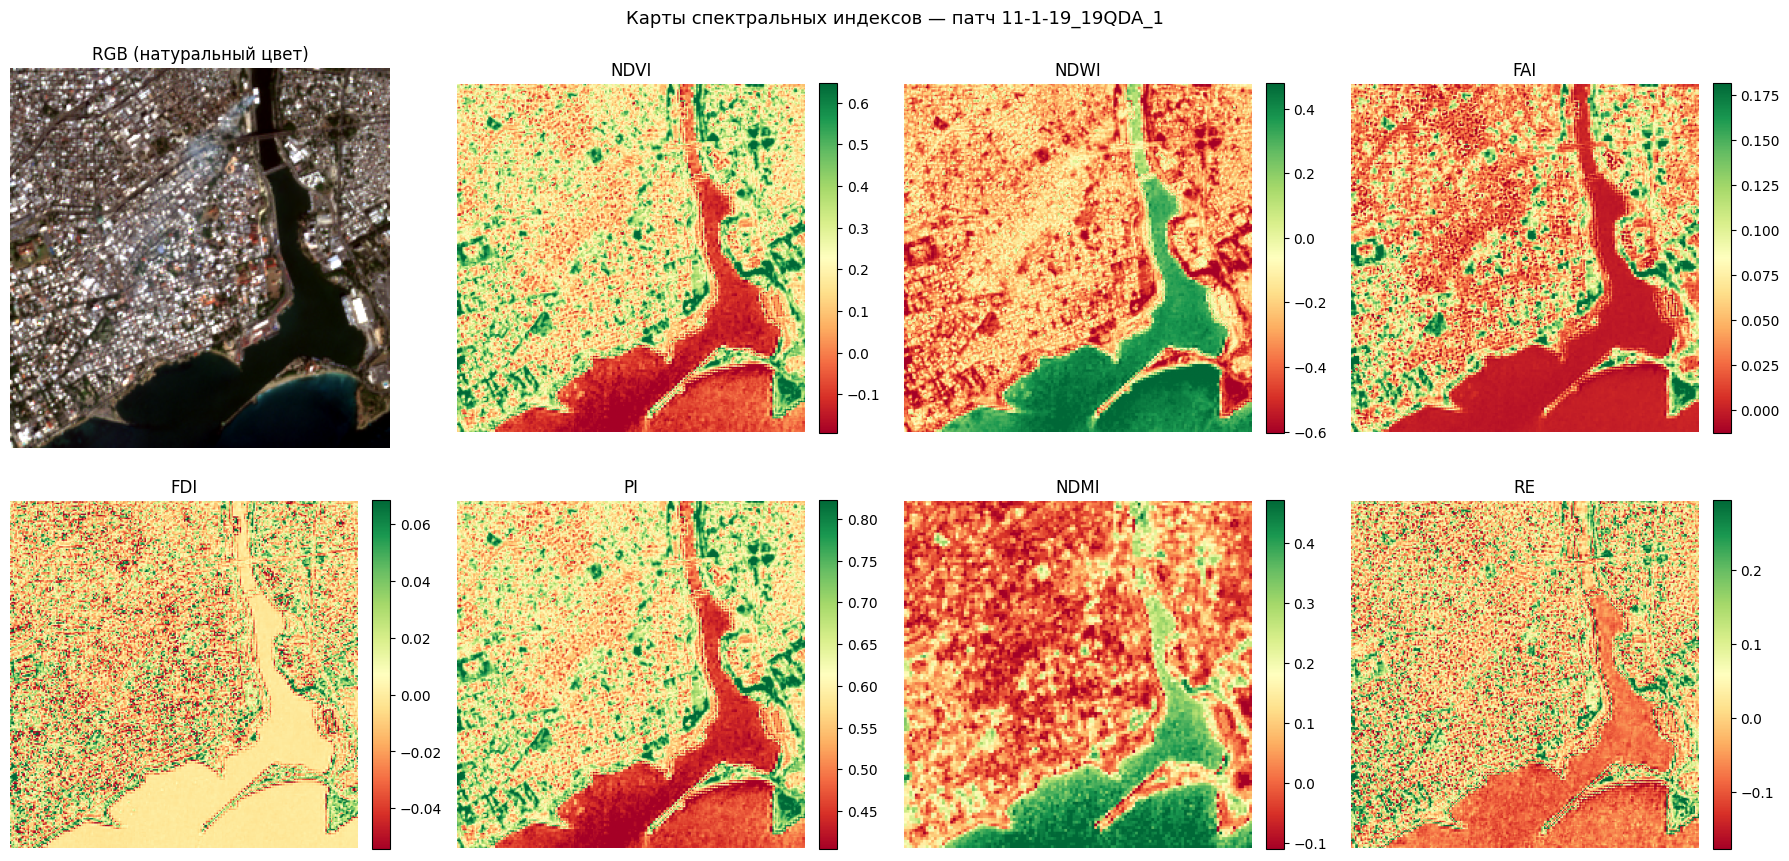

In [11]:
index_maps = {
    "NDVI": ndvi, "NDWI": ndwi, "FAI": fai,
    "FDI": fdi, "PI": pi, "NDMI": ndmi, "RE": re_idx
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

# RGB в первую позицию
axes[0].imshow(make_rgb(img))
axes[0].set_title("RGB (натуральный цвет)")
axes[0].axis("off")

for k, (name, arr) in enumerate(index_maps.items()):
    ax = axes[k + 1]
    p2, p98 = np.percentile(arr, [2, 98])
    im = ax.imshow(arr, cmap="RdYlGn", vmin=p2, vmax=p98)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle(f"Карты спектральных индексов — патч {sample_pid}", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Распределение значений индексов по классам

Ящики с усами (boxplot) — смотрим, насколько индексы разделяют классы.

In [12]:
# Собираем пиксели по классам из нескольких патчей
N_SAMPLE_PATCHES = 40
pixels_by_class = {cls: [] for cls in range(4)}

for pid in train_ids[:N_SAMPLE_PATCHES]:
    ip, lp = patch_paths(pid)
    try:
        with rasterio.open(ip) as s: arr = s.read().astype(np.float32)
        with rasterio.open(lp) as s: lb  = s.read(1).astype(np.uint8)
    except Exception:
        continue

    B8A_l = arr[8]; B04_l = arr[3]; B03_l = arr[2]
    B05_l = arr[4]; B08_l = arr[7]; B06_l = arr[5]; B11_l = arr[9]

    _ndvi = (B8A_l - B04_l) / (B8A_l + B04_l + eps)
    _fai  = B8A_l - B04_l - (B11_l - B04_l) * (865-665)/(1610-665)
    _fdi  = B08_l - B06_l - (B11_l - B06_l) * (833-740)/(1610-740)
    _pi   = B8A_l / (B8A_l + B04_l + eps)
    _ndwi = (B03_l - B8A_l) / (B03_l + B8A_l + eps)

    lb4 = label_to_4class(lb)
    for cls in range(4):
        m = lb4 == cls
        if m.sum() < 5:
            continue
        # Сохраняем [ndvi, fai, fdi, pi, ndwi] для каждого пикселя
        stacked = np.stack([_ndvi[m], _fai[m], _fdi[m], _pi[m], _ndwi[m]], axis=1)
        pixels_by_class[cls].append(stacked)

# Объединяем
for cls in range(4):
    if pixels_by_class[cls]:
        pixels_by_class[cls] = np.concatenate(pixels_by_class[cls], axis=0)
        print(f"  {TARGET_NAMES[cls]:<12}: {len(pixels_by_class[cls]):>8,} пикселей")
    else:
        pixels_by_class[cls] = np.zeros((0, 5))
        print(f"  {TARGET_NAMES[cls]:<12}: нет данных")

  Мусор       :       37 пикселей
  Водоросли   :      150 пикселей
  Пена        :       93 пикселей
  Вода        :    3,724 пикселей


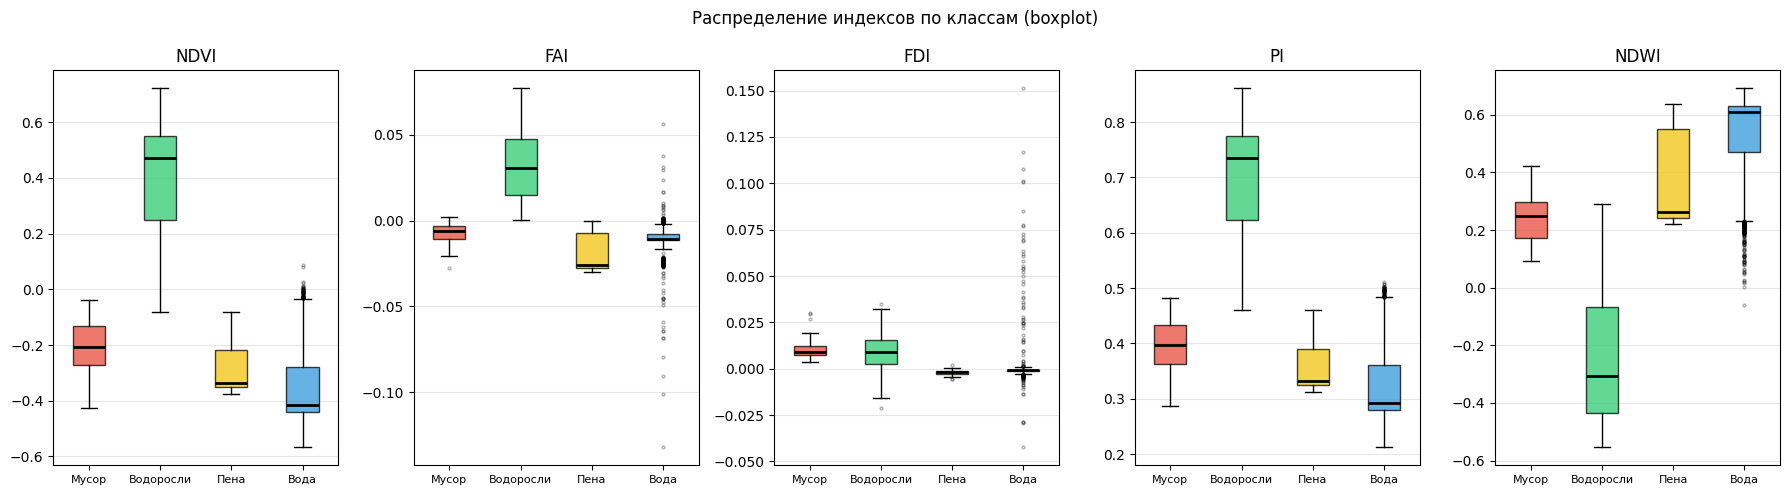

In [13]:
# Boxplot для каждого индекса
idx_plot_names = ["NDVI", "FAI", "FDI", "PI", "NDWI"]
N_SAMPLE = 2000   # берём выборку для скорости

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for col, (ax, iname) in enumerate(zip(axes, idx_plot_names)):
    data_per_cls = []
    labels_per_cls = []
    colors_per_cls = []

    for cls in range(4):
        pix = pixels_by_class[cls]
        if len(pix) == 0:
            continue
        sample = pix[np.random.choice(len(pix), min(N_SAMPLE, len(pix)), replace=False), col]
        data_per_cls.append(sample)
        labels_per_cls.append(TARGET_NAMES[cls])
        colors_per_cls.append(CLASS_COLORS[cls])

    bp = ax.boxplot(data_per_cls, patch_artist=True, notch=False,
                    medianprops={"color": "black", "linewidth": 2},
                    flierprops={"markersize": 2, "alpha": 0.3})
    for patch, clr in zip(bp["boxes"], colors_per_cls):
        patch.set_facecolor(clr)
        patch.set_alpha(0.75)

    ax.set_xticklabels(labels_per_cls, fontsize=8)
    ax.set_title(iname)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Распределение индексов по классам (boxplot)", fontsize=12)
plt.tight_layout()
plt.show()

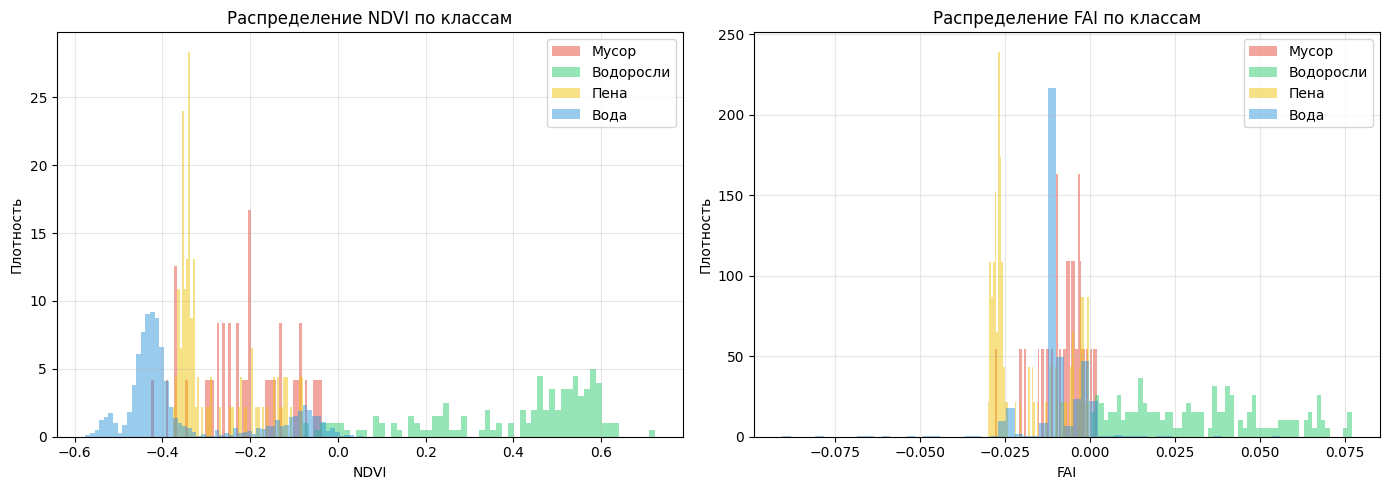

In [14]:
# Гистограммы overlapping — NDVI и FAI (самые информативные для мусора/водорослей)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, (ax, iname) in enumerate(zip(axes, ["NDVI", "FAI"])):
    for cls in range(4):
        pix = pixels_by_class[cls]
        if len(pix) == 0:
            continue
        sample = pix[np.random.choice(len(pix), min(N_SAMPLE, len(pix)), replace=False), col]
        ax.hist(sample, bins=60, alpha=0.5, label=TARGET_NAMES[cls],
                color=CLASS_COLORS[cls], density=True)
    ax.set_xlabel(iname)
    ax.set_ylabel("Плотность")
    ax.set_title(f"Распределение {iname} по классам")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Итоговая функция вычисления признаков

Используется в следующем ноутбуке для построения датасета.

In [15]:
def compute_indices(img):
    """
    Принимает снимок (11, H, W) → возвращает (18, H, W):
      11 исходных каналов + 7 спектральных индексов.

    Индексы (в порядке): NDVI, NDWI, FAI, FDI, PI, NDMI, RE
    """
    eps = 1e-6
    B02_ = img[1];  B03_ = img[2];  B04_ = img[3]
    B05_ = img[4];  B06_ = img[5]
    B08_ = img[7];  B8A_ = img[8]
    B11_ = img[9]

    ndvi_  = (B8A_ - B04_) / (B8A_ + B04_ + eps)
    ndwi_  = (B03_ - B8A_) / (B03_ + B8A_ + eps)
    fai_   = B8A_ - B04_ - (B11_ - B04_) * (865 - 665) / (1610 - 665)
    fdi_   = B08_ - B06_ - (B11_ - B06_) * (833 - 740) / (1610 - 740)
    pi_    = B8A_ / (B8A_ + B04_ + eps)
    ndmi_  = (B8A_ - B11_) / (B8A_ + B11_ + eps)
    re_    = (B05_ - B04_) / (B05_ + B04_ + eps)

    idx_stack = np.stack([ndvi_, ndwi_, fai_, fdi_, pi_, ndmi_, re_], axis=0)
    return np.concatenate([img, idx_stack], axis=0)

FEATURE_NAMES = BAND_NAMES + ["NDVI","NDWI","FAI","FDI","PI","NDMI","RE"]
N_FEATURES    = len(FEATURE_NAMES)

print(f"Итого признаков: {N_FEATURES}")
print("Признаки:", FEATURE_NAMES)

Итого признаков: 18
Признаки: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'FAI', 'FDI', 'PI', 'NDMI', 'RE']


In [16]:
# Проверяем функцию
ip, _ = patch_paths(train_ids[0])
with rasterio.open(ip) as s:
    test_img = s.read().astype(np.float32)

result = compute_indices(test_img)
print(f"Вход:  {test_img.shape}")
print(f"Выход: {result.shape}  ✓")

print("\nСтатистика по признакам (первый патч):")
print(f"  {'Признак':<8} {'min':>9} {'max':>9} {'mean':>9}")
print("  " + "-" * 38)
for k, fname in enumerate(FEATURE_NAMES):
    v = result[k]
    print(f"  {fname:<8} {v.min():>9.3f} {v.max():>9.3f} {v.mean():>9.3f}")

Вход:  (11, 256, 256)
Выход: (18, 256, 256)  ✓

Статистика по признакам (первый патч):
  Признак        min       max      mean
  --------------------------------------
  B01          0.093     0.113     0.098
  B02          0.081     0.217     0.091
  B03          0.062     0.238     0.072
  B04          0.042     0.271     0.052
  B05          0.037     0.180     0.046
  B06          0.035     0.212     0.045
  B07          0.036     0.212     0.046
  B08          0.030     0.256     0.040
  B8A          0.034     0.218     0.045
  B11          0.020     0.166     0.030
  B12          0.014     0.100     0.022
  NDVI        -0.345     0.286    -0.076
  NDWI        -0.286     0.398     0.233
  FAI         -0.070     0.071    -0.003
  FDI         -0.052     0.089    -0.003
  PI           0.327     0.643     0.462
  NDMI         0.038     0.297     0.196
  RE          -0.306     0.225    -0.063


In [17]:
print("Спектральные индексы вычислены и проверены.")
print(f"Функция compute_indices(): (11, H, W) → ({N_FEATURES}, H, W)")
print()
print("Далее: 04_dataset_preparation.ipynb")

Спектральные индексы вычислены и проверены.
Функция compute_indices(): (11, H, W) → (18, H, W)

Далее: 04_dataset_preparation.ipynb
